In [6]:
# Install and import the datasets library
!pip install datasets -q

import pandas as pd

from datasets import load_dataset

In [2]:
# Load dataset
dataset = load_dataset("splevine/netflix-app-review-sample")

# Convert to pandas DataFrame
df = dataset["netflix"].to_pandas()
df.head()

README.md:   0%|          | 0.00/536 [00:00<?, ?B/s]

data/netflix-00000-of-00001.parquet:   0%|          | 0.00/567k [00:00<?, ?B/s]

Generating netflix split:   0%|          | 0/5000 [00:00<?, ? examples/s]

,review_id,platform,app_id,rating,content,language,created_at,title
0,65ce4096-51c7-44e8-849b-d4b81eaf8c01,google_play,com.netflix.mediaclient,1,"I have a stable network, but it keeps on loadi...",en,2025-06-26 10:57:22,None
1,83e3d9e8-b631-4ae9-90bf-3fe4baf89a26,google_play,com.netflix.mediaclient,1,my payment to Netflix is not showing. I can't ...,en,2025-06-26 10:50:55,None
2,94cd7e69-1deb-4e9e-9dac-bb3a310c27fd,google_play,com.netflix.mediaclient,1,"used to be one of the best streaming platform,...",en,2025-06-26 10:49:03,None
3,4d0f9c50-390b-4335-88b6-9f87146f6492,google_play,com.netflix.mediaclient,5,good,en,2025-06-26 10:44:58,None
4,a9b69dd2-2e61-4c61-9cbc-bbb1ba192fd0,google_play,com.netflix.mediaclient,5,Netflix is better but don't use it's copied ve...,en,2025-06-26 10:43:44,None


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   review_id   5000 non-null   object
 1   platform    5000 non-null   object
 2   app_id      5000 non-null   object
 3   rating      5000 non-null   int64 
 4   content     5000 non-null   object
 5   language    5000 non-null   object
 6   created_at  5000 non-null   object
 7   title       1000 non-null   object
dtypes: int64(1), object(7)
memory usage: 312.6+ KB


## Data Cleaning and NLP Preprocessing

Before applying NLP and machine learning, I cleaned the review dataset to make sure the text and rating fields were usable. The review text is the main input feature, and the rating score is used to define the sentiment target variable. Therefore, rows with missing review text or missing ratings were removed. Duplicate rows were also removed to avoid counting the same review multiple times.

The rating variable was converted to numeric format so it could be used to create a binary sentiment label. Reviews with scores of 1 or 2 were labeled as negative sentiment, while reviews with scores of 4 or 5 were labeled as non-negative sentiment. Reviews with a score of 3 were excluded because they are more neutral or mixed, which could make the classification task less clear.

For NLP preprocessing, the review text was lowercased, URLs were removed, non-letter characters were removed, and extra whitespace was cleaned. These steps make the text more consistent and reduce noise before converting the reviews into numerical features.

In [7]:
# Make a copy of the dataset
df_clean = df.copy()

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Remove rows with missing review text or missing rating
df_clean = df_clean.dropna(subset=["content", "rating"])

# Convert review text to string format
df_clean["content"] = df_clean["content"].astype(str)

# Convert rating to numeric format
df_clean["rating"] = pd.to_numeric(df_clean["rating"], errors="coerce")

# Remove rows where rating could not be converted to numeric
df_clean = df_clean.dropna(subset=["rating"])

print("Original shape:", df.shape)
print("Cleaned shape:", df_clean.shape)

Original shape: (5000, 8)
Cleaned shape: (3000, 8)


The dataset originally contained 5,000 rows. A duplicate check showed that 2,000 rows were exact duplicates, so these duplicate observations were removed. This reduced the dataset to 3,000 unique reviews. Removing duplicates is important because repeated reviews could overweight certain opinions and bias both the NLP analysis and the machine learning model.

#### Target Variable Code

In [8]:
# Remove neutral 3-star reviews to create a clearer binary classification task
df_model = df_clean[df_clean["rating"] != 3].copy()

# Create binary target variable
# 1 = negative sentiment, 0 = non-negative sentiment
df_model["negative_sentiment"] = (df_model["rating"] <= 2).astype(int)

df_model["negative_sentiment"].value_counts()

negative_sentiment
0    1655
1    1130
Name: count, dtype: int64

In [9]:
# Check number of full duplicate rows
df.duplicated().sum()

np.int64(2000)

After removing neutral 3-star reviews, the final modeling dataset contains 2,785 reviews. Of these, 1,130 reviews are labeled as negative sentiment and 1,655 reviews are labeled as non-negative sentiment. This class distribution is moderately imbalanced, with more non-negative reviews than negative reviews, but both classes have enough observations for supervised classification. Because the business goal is to identify dissatisfied users, I use class balancing in the model and evaluate performance using precision, recall, and F1-score rather than accuracy alone.

#### Text preprocessing

In [10]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df_model["clean_review"] = df_model["content"].apply(clean_text)

df_model[["content", "clean_review", "rating", "negative_sentiment"]].head()

,content,clean_review,rating,negative_sentiment
0,"I have a stable network, but it keeps on loadi...",i have a stable network but it keeps on loadin...,1,1
1,my payment to Netflix is not showing. I can't ...,my payment to netflix is not showing i can t f...,1,1
2,"used to be one of the best streaming platform,...",used to be one of the best streaming platform ...,1,1
3,good,good,5,0
4,Netflix is better but don't use it's copied ve...,netflix is better but don t use it s copied ve...,5,0


## Exploratory NLP Analysis and Visualization

In this section, I explore the Netflix app reviews before modeling. The goal is to understand the distribution of ratings, the balance between negative and non-negative sentiment, the length of review text, and the most common words used in negative versus non-negative reviews.

These visualizations support the business problem because they show whether dissatisfaction is common in the review data and help identify recurring themes in customer feedback. The analysis also supports the machine learning task by showing that the review text contains meaningful patterns that can be transformed into predictive features.

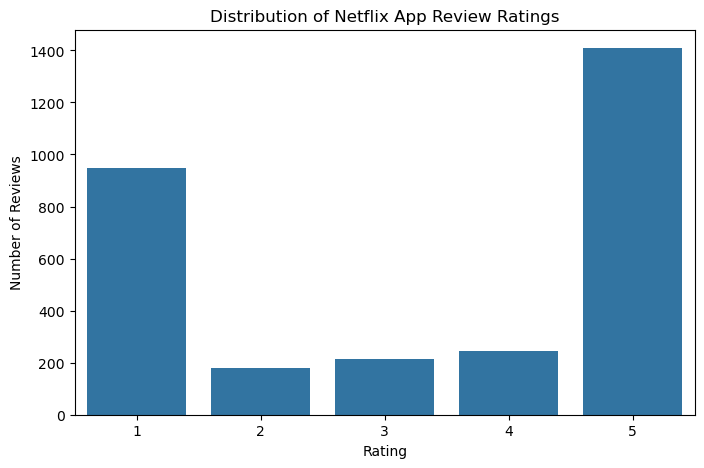

rating
1     950
2     180
3     215
4     246
5    1409
Name: count, dtype: int64

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.countplot(data=df_clean, x="rating", order=sorted(df_clean["rating"].unique()))
plt.title("Distribution of Netflix App Review Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Reviews")
plt.show()

df_clean["rating"].value_counts().sort_index()

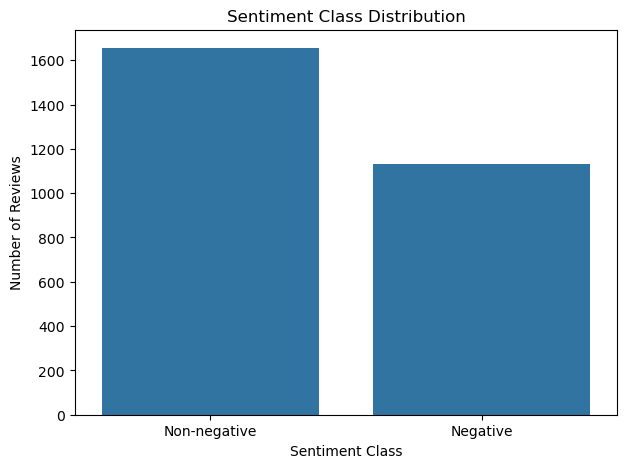

negative_sentiment
Non-negative    1655
Negative        1130
Name: count, dtype: int64

In [13]:
sentiment_counts = df_model["negative_sentiment"].value_counts().rename(index={0: "Non-negative", 1: "Negative"})

plt.figure(figsize=(7, 5))
sns.barplot(x=sentiment_counts.index, y=sentiment_counts.values)
plt.title("Sentiment Class Distribution")
plt.xlabel("Sentiment Class")
plt.ylabel("Number of Reviews")
plt.show()

sentiment_counts

In [14]:
df_model["negative_sentiment"].value_counts(normalize=True).rename(index={0: "Non-negative", 1: "Negative"})

negative_sentiment
Non-negative    0.594255
Negative        0.405745
Name: proportion, dtype: float64

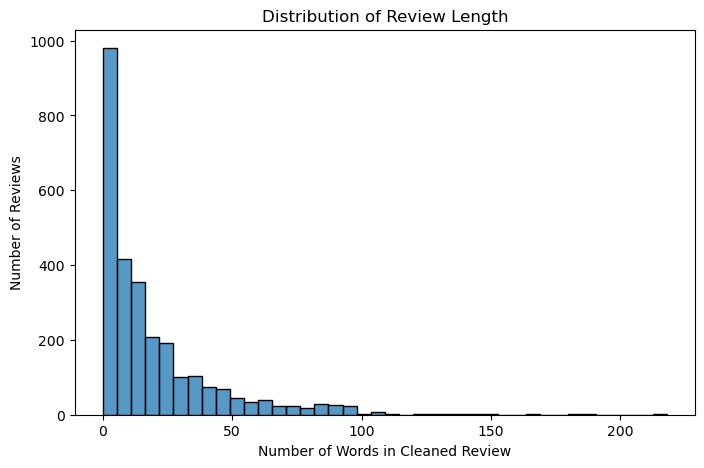

count    2785.000000
mean       19.281149
std        23.756131
min         0.000000
25%         3.000000
50%        10.000000
75%        26.000000
max       218.000000
Name: review_length, dtype: float64

In [15]:
df_model["review_length"] = df_model["clean_review"].apply(lambda x: len(x.split()))

plt.figure(figsize=(8, 5))
sns.histplot(df_model["review_length"], bins=40)
plt.title("Distribution of Review Length")
plt.xlabel("Number of Words in Cleaned Review")
plt.ylabel("Number of Reviews")
plt.show()

df_model["review_length"].describe()

The review-length analysis shows how much text users typically provide in their reviews. This matters for NLP because longer reviews may contain more detailed complaints or explanations, while very short reviews may contain limited information. Comparing review length by sentiment also helps show whether negative users tend to provide more detailed feedback, which can be useful for identifying app-experience problems.

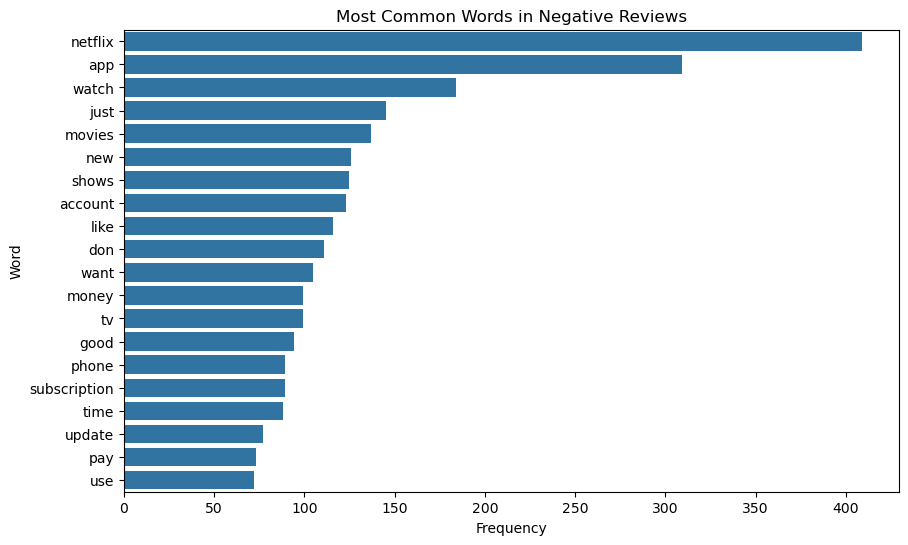

,word,count
8,netflix,409
1,app,309
19,watch,184
4,just,145
7,movies,137
9,new,126
12,shows,125
0,account,123
5,like,116
2,don,111


In [16]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

negative_reviews = df_model[df_model["negative_sentiment"] == 1]["clean_review"]

negative_vectorizer = CountVectorizer(stop_words="english", max_features=20)
negative_counts = negative_vectorizer.fit_transform(negative_reviews)

negative_word_freq = pd.DataFrame({
    "word": negative_vectorizer.get_feature_names_out(),
    "count": negative_counts.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=negative_word_freq, x="count", y="word")
plt.title("Most Common Words in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

negative_word_freq

This visualization identifies the most frequent words in negative Netflix app reviews. These words help reveal recurring dissatisfaction themes in user feedback. If terms related to loading, payment, account access, updates, crashes, ads, downloads, or app performance appear frequently, they suggest that negative sentiment is connected to concrete mobile app experience problems rather than general dissatisfaction alone.

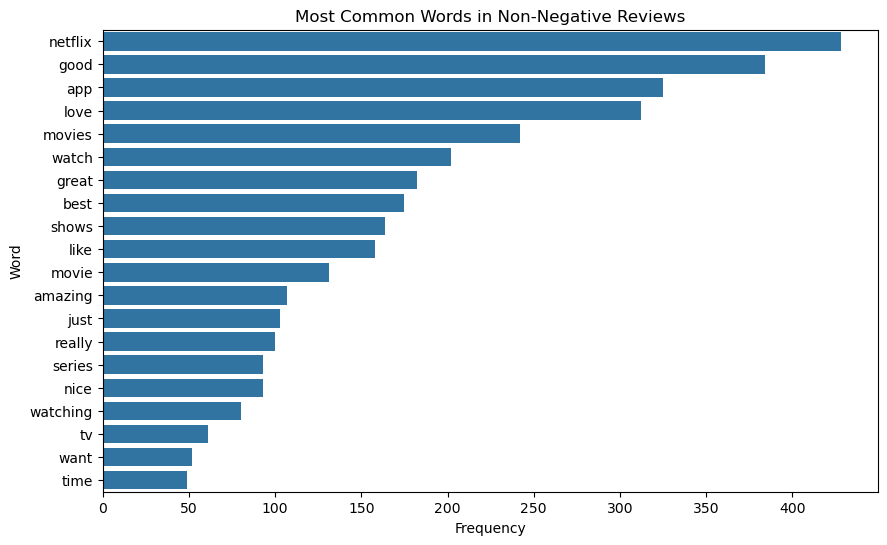

,word,count
10,netflix,428
3,good,384
1,app,325
7,love,312
9,movies,242
18,watch,202
4,great,182
2,best,175
14,shows,164
6,like,158


In [17]:
nonnegative_reviews = df_model[df_model["negative_sentiment"] == 0]["clean_review"]

nonnegative_vectorizer = CountVectorizer(stop_words="english", max_features=20)
nonnegative_counts = nonnegative_vectorizer.fit_transform(nonnegative_reviews)

nonnegative_word_freq = pd.DataFrame({
    "word": nonnegative_vectorizer.get_feature_names_out(),
    "count": nonnegative_counts.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=nonnegative_word_freq, x="count", y="word")
plt.title("Most Common Words in Non-Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.show()

nonnegative_word_freq

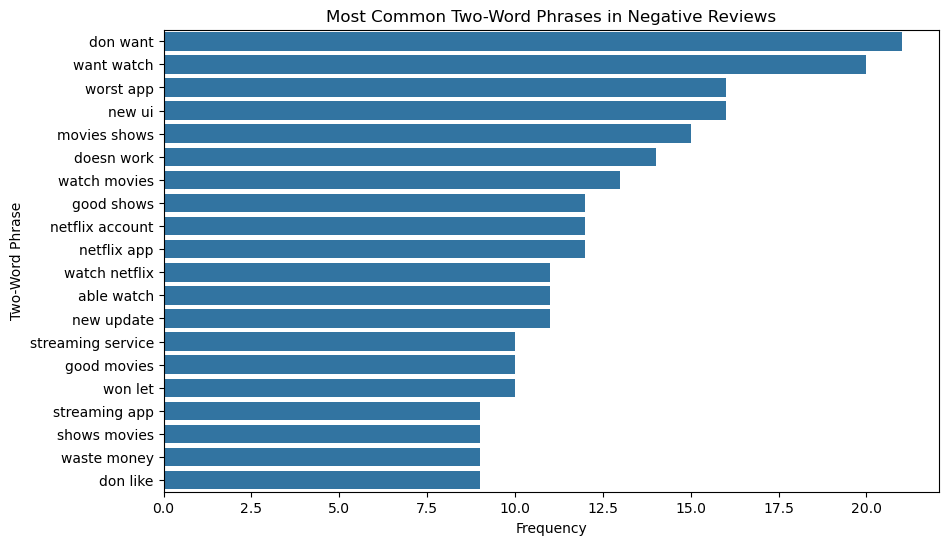

,bigram,count
3,don want,21
14,want watch,20
19,worst app,16
9,new ui,16
6,movies shows,15
1,doesn work,14
16,watch movies,13
5,good shows,12
7,netflix account,12
8,netflix app,12


In [18]:
negative_bigram_vectorizer = CountVectorizer(
    stop_words="english",
    ngram_range=(2, 2),
    max_features=20
)

negative_bigram_counts = negative_bigram_vectorizer.fit_transform(negative_reviews)

negative_bigram_freq = pd.DataFrame({
    "bigram": negative_bigram_vectorizer.get_feature_names_out(),
    "count": negative_bigram_counts.toarray().sum(axis=0)
}).sort_values(by="count", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=negative_bigram_freq, x="count", y="bigram")
plt.title("Most Common Two-Word Phrases in Negative Reviews")
plt.xlabel("Frequency")
plt.ylabel("Two-Word Phrase")
plt.show()

negative_bigram_freq

## Feature Engineering: Transforming Text into Numerical Features

Machine learning models cannot directly read raw text, so the cleaned Netflix review text must be transformed into numerical features. I use TF-IDF, which stands for Term Frequency-Inverse Document Frequency. TF-IDF gives higher weight to words or phrases that are important within a review but not overly common across all reviews.

This is appropriate for the Netflix app review dataset because the goal is to identify language patterns associated with negative sentiment. For example, words and phrases related to app problems, watching issues, account friction, or interface complaints may help the model distinguish negative reviews from non-negative reviews.

I use the cleaned review text as the input variable and the rating-based negative sentiment label as the target variable. The TF-IDF vectorizer includes both unigrams and bigrams, meaning it captures single words such as "account" and two-word phrases such as "worst app" or "new ui."

In [19]:
# Define input text feature and target variable
X = df_model["clean_review"]
y = df_model["negative_sentiment"]

print("Number of reviews:", X.shape[0])
print("Target distribution:")
print(y.value_counts())
print(y.value_counts(normalize=True))

Number of reviews: 2785
Target distribution:
negative_sentiment
0    1655
1    1130
Name: count, dtype: int64
negative_sentiment
0    0.594255
1    0.405745
Name: proportion, dtype: float64


The input variable `X` contains the cleaned Netflix app review text, and the target variable `y` contains the binary sentiment label. The modeling dataset includes 2,785 reviews after removing duplicates and neutral 3-star reviews.

The target distribution shows that 1,655 reviews, or 59.4%, are non-negative, while 1,130 reviews, or 40.6%, are negative. This confirms that both classes are well represented for supervised classification. The dataset is moderately imbalanced, but not severely imbalanced. Because the business objective is to identify dissatisfied users, later model evaluation should consider precision, recall, and F1-score rather than relying only on accuracy.

#### Train-Test Split

In [20]:
from sklearn.model_selection import train_test_split

# Split the data into training and testing sets
# Stratify keeps the negative/non-negative class balance similar in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))
print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

Training set size: 2228
Testing set size: 557

Training target distribution:
negative_sentiment
0    0.594255
1    0.405745
Name: proportion, dtype: float64

Testing target distribution:
negative_sentiment
0    0.594255
1    0.405745
Name: proportion, dtype: float64


The data was split into 2,228 training reviews and 557 testing reviews using an 80/20 train-test split. I used stratified sampling so that the class balance would remain consistent across both sets.

The training set and testing set both contain 59.4% non-negative reviews and 40.6% negative reviews. This is important because it ensures that the model is trained and evaluated on similar sentiment distributions. It also makes the test-set evaluation more reliable because the test data reflects the same class balance as the full modeling dataset.

#### TF-IDF Vectorization

In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Convert cleaned review text into numerical TF-IDF features
tfidf = TfidfVectorizer(
    stop_words="english",
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print("Training TF-IDF matrix shape:", X_train_tfidf.shape)
print("Testing TF-IDF matrix shape:", X_test_tfidf.shape)

Training TF-IDF matrix shape: (2228, 2998)
Testing TF-IDF matrix shape: (557, 2998)


The TF-IDF transformation converted the cleaned review text into numerical matrices for machine learning. The training matrix has 2,228 rows and 2,998 columns, meaning there are 2,228 training reviews represented by 2,998 text-based features. The testing matrix has 557 rows and the same 2,998 columns, meaning the test reviews were transformed using the same vocabulary learned from the training data.

This is important because each column represents a word or two-word phrase from the cleaned review text. Since the vectorizer uses both unigrams and bigrams, it can capture individual terms such as "account" as well as phrases such as "worst app" or "new ui." The vectorizer was fit only on the training data and then applied to the test data, which prevents data leakage and keeps the evaluation valid.

In [24]:
# Display a sample of learned TF-IDF feature names
feature_names = tfidf.get_feature_names_out()

print("Number of TF-IDF features:", len(feature_names))
print("Sample features:")
print(feature_names[:30])

Number of TF-IDF features: 2998
Sample features:
['aap' 'aati' 'ability' 'able' 'able change' 'able download' 'able load'
 'able play' 'able use' 'able watch' 'abroad' 'absolute' 'absolute trash'
 'absolutely' 'absolutely adore' 'absolutely amazing' 'absolutely does'
 'absolutely hate' 'absolutely love' 'absolutely ridiculous'
 'absolutely terrible' 'absurd' 'academia' 'acc' 'access' 'access account'
 'access netflix' 'accidentally' 'account' 'account absolutely']


The TF-IDF vectorizer created 2,998 numerical text features from the training reviews. The sample features show that the model captures both single words and two-word phrases. For example, the feature list includes single-word terms such as "access" and "account," as well as bigrams such as "able download," "able watch," "access account," and "access netflix."

This confirms that the feature engineering step is aligned with the NLP findings. Earlier exploratory analysis showed that negative reviews often discussed watching issues, account friction, and app usability. The TF-IDF features preserve these types of language patterns in numerical form so that the machine learning model can learn which words and phrases are most associated with negative sentiment.

## Machine Learning Model: Logistic Regression Classification

After transforming the cleaned review text into TF-IDF numerical features, I build a supervised machine learning classification model. The goal is to predict whether a Netflix app review reflects negative sentiment.

I use Logistic Regression as the main predictive model. This model is appropriate for text classification because it performs well with high-dimensional sparse TF-IDF features and produces interpretable coefficients. These coefficients can later help identify which words or phrases are most strongly associated with negative sentiment.

The model is trained on the TF-IDF features from the training set and then used to predict sentiment labels for the unseen test set.

In [25]:
from sklearn.linear_model import LogisticRegression

# Build and train logistic regression classifier
log_reg_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

log_reg_model.fit(X_train_tfidf, y_train)

# Predict sentiment labels on the test set
y_pred = log_reg_model.predict(X_test_tfidf)

In [26]:
# Check prediction output
print("Number of test predictions:", len(y_pred))
print("Predicted class distribution:")
print(pd.Series(y_pred).value_counts())
print(pd.Series(y_pred).value_counts(normalize=True))

Number of test predictions: 557
Predicted class distribution:
1    280
0    277
Name: count, dtype: int64
1    0.502693
0    0.497307
Name: proportion, dtype: float64


The Logistic Regression model was trained using the TF-IDF feature matrix from the training set and then used to predict sentiment labels for the 557 reviews in the test set. The model produced predictions for every test review, confirming that the engineered text features were successfully passed into the classifier.

The predicted class distribution is nearly balanced: 280 reviews, or 50.3%, were predicted as negative, and 277 reviews, or 49.7%, were predicted as non-negative. This is reasonable because the model uses `class_weight="balanced"`, which helps prevent the classifier from simply favoring the larger non-negative class. Since Netflix’s business objective is to identify dissatisfied users, a model that actively flags negative sentiment is useful, but the next step is to evaluate whether these predictions are accurate using precision, recall, F1-score, and a confusion matrix.

## Model Evaluation

After training the Logistic Regression sentiment classifier, I evaluate its performance on the unseen test set. Since this is a binary classification problem, I use accuracy, precision, recall, F1-score, and a confusion matrix.

Accuracy measures the overall percentage of correct predictions. Precision measures how many reviews predicted as negative were actually negative. Recall measures how many actual negative reviews the model successfully identified. F1-score balances precision and recall.

For this business problem, recall and F1-score are especially important because Netflix wants to detect dissatisfied users reliably. If the model misses many negative reviews, Netflix may fail to notice important app-experience problems.

In [29]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Logistic Regression Model Performance")
print("Accuracy:", round(accuracy, 4))
print("Precision:", round(precision, 4))
print("Recall:", round(recall, 4))
print("F1-score:", round(f1, 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Non-negative", "Negative"]))

Logistic Regression Model Performance
Accuracy: 0.8025
Precision: 0.7071
Recall: 0.8761
F1-score: 0.7826

Classification Report:
              precision    recall  f1-score   support

Non-negative       0.90      0.75      0.82       331
    Negative       0.71      0.88      0.78       226

    accuracy                           0.80       557
   macro avg       0.80      0.81      0.80       557
weighted avg       0.82      0.80      0.80       557



The Logistic Regression model performs well on the unseen test set of 557 reviews. The model achieves an overall accuracy of 0.8025, meaning it correctly classifies about 80.3% of test reviews.

For the negative sentiment class, the model has a precision of 0.7071, recall of 0.8761, and F1-score of 0.7826. The recall score is especially important for Netflix’s business objective because it means the model successfully identifies about 87.6% of truly negative reviews. In other words, the model is effective at detecting dissatisfied users, which is valuable if Netflix wants to monitor app problems and reduce churn risk.

The precision score of 0.7071 means that about 70.7% of reviews flagged as negative are actually negative. This suggests that the model may produce some false positives, but that tradeoff is acceptable in this context because falsely flagging a review for further review is less costly than missing a dissatisfied customer.

The classification report also shows that the model performs well on non-negative reviews, with a precision of 0.90 and F1-score of 0.82. Overall, the weighted average F1-score is 0.80, showing balanced performance across both sentiment classes.

From a business perspective, this model is useful because it can screen large volumes of app reviews and identify most negative experiences automatically. This would help Netflix prioritize customer pain points such as app reliability, account issues, watching problems, and user interface complaints.

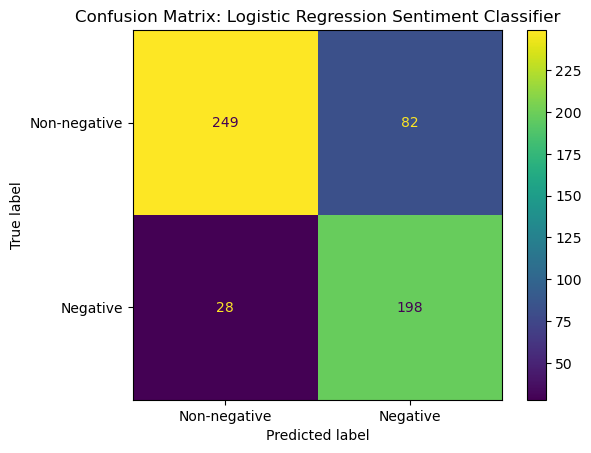

array([[249,  82],
       [ 28, 198]])

In [30]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-negative", "Negative"]
)

disp.plot()
plt.title("Confusion Matrix: Logistic Regression Sentiment Classifier")
plt.show()

cm

The confusion matrix provides a more detailed view of the model’s predictions. Out of 331 actual non-negative reviews, the model correctly classified 249 and incorrectly flagged 82 as negative. Out of 226 actual negative reviews, the model correctly identified 198 and missed only 28.

This result is strong for Netflix’s business objective because the model captures most dissatisfied users. The most important number is the 198 true positives for negative sentiment out of 226 actual negative reviews, which corresponds to a negative-class recall of 87.6%. Only 28 negative reviews were missed, meaning the model is relatively effective at finding reviews that signal customer frustration.

The tradeoff is that 82 non-negative reviews were incorrectly flagged as negative. However, this is acceptable in a customer-experience monitoring context because reviewing extra flagged comments is less costly than missing serious app complaints. For Netflix, false negatives are more risky because they represent dissatisfied users whose issues may go unnoticed.

Overall, the confusion matrix supports the conclusion that the Logistic Regression model is useful for large-scale review monitoring. It can help Netflix identify negative app experiences quickly and prioritize issues that may contribute to dissatisfaction and churn risk.

#### Cross-Validation

In [31]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline

# Build a full modeling pipeline for cross-validation
log_reg_pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        stop_words="english",
        max_features=5000,
        ngram_range=(1, 2),
        min_df=2
    )),
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ))
])

# 5-fold cross-validation using F1-score
cv_f1_scores = cross_val_score(
    log_reg_pipeline,
    X,
    y,
    cv=5,
    scoring="f1"
)

print("5-Fold Cross-Validation F1 Scores:", cv_f1_scores)
print("Mean CV F1-score:", round(cv_f1_scores.mean(), 4))
print("Standard Deviation:", round(cv_f1_scores.std(), 4))

5-Fold Cross-Validation F1 Scores: [0.84104628 0.83534137 0.8266129  0.79174484 0.75877193]
Mean CV F1-score: 0.8107
Standard Deviation: 0.0311


The 5-fold cross-validation results provide an additional validation check beyond the single train-test split. Across the five folds, the F1-scores were 0.8410, 0.8353, 0.8266, 0.7917, and 0.7588. The mean cross-validation F1-score was 0.8107, with a standard deviation of 0.0311.

This suggests that the Logistic Regression model generalizes reasonably well across different subsets of the data. The standard deviation is relatively small, meaning the model’s performance is fairly stable rather than depending heavily on one particular split.

The test-set F1-score was 0.7826, which is slightly below the cross-validation average but still within a reasonable range. From a business perspective, this supports the conclusion that the model can reliably identify negative Netflix app reviews and could be used as a scalable monitoring tool for customer dissatisfaction.

## Additional Classification Model Comparison

To strengthen the modeling implementation, I compare Logistic Regression with two additional classification models: Decision Tree and Random Forest. Logistic Regression serves as the baseline text classification model, Decision Tree provides an explainable comparison model, and Random Forest provides an ensemble-based comparison model.

All three models use the same TF-IDF training and testing features, so the comparison is fair. I evaluate the models using accuracy, precision, recall, and F1-score, with special attention to F1-score and recall because the business goal is to identify negative Netflix app reviews reliably.

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Define classification models
classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),
    "Decision Tree": DecisionTreeClassifier(
        class_weight="balanced",
        random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=200,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    )
}

# Train and evaluate each model
model_results = []

for model_name, clf in classification_models.items():
    clf.fit(X_train_tfidf, y_train)
    preds = clf.predict(X_test_tfidf)
    
    model_results.append({
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, preds),
        "Precision": precision_score(y_test, preds),
        "Recall": recall_score(y_test, preds),
        "F1-score": f1_score(y_test, preds)
    })

model_results_df = pd.DataFrame(model_results)

# Sort by F1-score because F1 balances precision and recall
model_results_df = model_results_df.sort_values(by="F1-score", ascending=False)

model_results_df

,Model,Accuracy,Precision,Recall,F1-score
2,Random Forest,0.833034,0.812207,0.765487,0.788155
0,Logistic Regression,0.802513,0.707143,0.876106,0.782609
1,Decision Tree,0.766607,0.733010,0.668142,0.699074


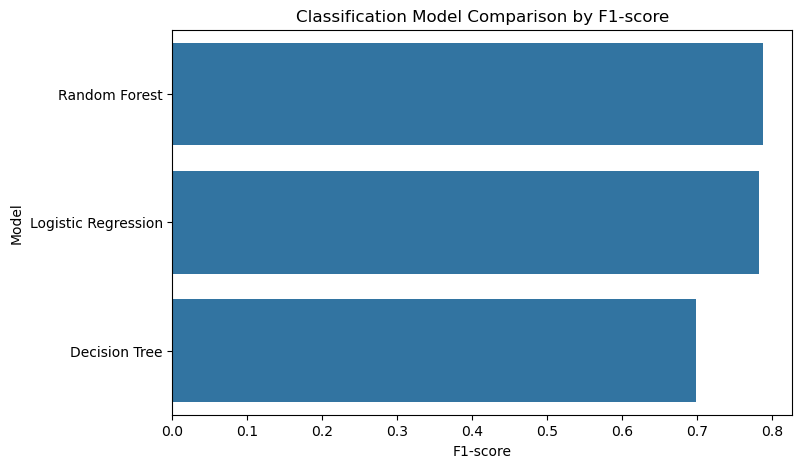

In [33]:
plt.figure(figsize=(8, 5))
sns.barplot(data=model_results_df, x="F1-score", y="Model")
plt.title("Classification Model Comparison by F1-score")
plt.xlabel("F1-score")
plt.ylabel("Model")
plt.show()

The classification model comparison shows that Random Forest achieved the highest overall performance by F1-score, with an accuracy of 0.8330, precision of 0.8122, recall of 0.7655, and F1-score of 0.7882. Logistic Regression performed very similarly in F1-score, with an accuracy of 0.8025, precision of 0.7071, recall of 0.8761, and F1-score of 0.7826. Decision Tree performed the weakest, with an accuracy of 0.7666 and F1-score of 0.6991.

Random Forest has the best F1-score, which means it provides the strongest balance between precision and recall. However, Logistic Regression has the highest recall at 0.8761, meaning it identifies the largest share of truly negative reviews. This is important for Netflix because the business goal is to detect dissatisfied users and app-experience problems, not just maximize overall accuracy.

Because the Random Forest model has slightly better overall F1-score but Logistic Regression has stronger recall and better interpretability, the final model choice depends on business priority. If Netflix wants the best balanced classifier, Random Forest is preferred. If Netflix wants to catch as many negative reviews as possible and understand which text terms drive dissatisfaction, Logistic Regression remains highly useful.

## Interpretation and Business Insights

The analysis shows that negative Netflix app reviews represent a substantial part of the review data. After removing duplicates and neutral 3-star reviews, 1,130 out of 2,785 reviews were labeled as negative sentiment, or about 40.6% of the modeling dataset. This indicates that dissatisfaction is not isolated and should be treated as a meaningful customer-experience signal.

The exploratory NLP results suggest that negative sentiment is closely related to the mobile app experience. In negative reviews, the most frequent terms included "netflix" with 409 mentions, "app" with 309 mentions, "watch" with 184 mentions, and "account" with 123 mentions. The negative bigram analysis also identified phrases such as "don want" with 21 mentions, "want watch" with 20 mentions, "worst app" with 16 mentions, and "new ui" with 16 mentions. These patterns suggest that users are not only giving low ratings because of general dissatisfaction; many complaints are connected to watching friction, account-related issues, app usability, and dissatisfaction with interface changes.

The predictive model confirms that review text contains useful signals for identifying dissatisfied users. The Logistic Regression model achieved 80.25% accuracy and a negative-class recall of 87.61%, correctly identifying 198 out of 226 actual negative reviews. This means the model can help Netflix detect most negative app experiences automatically instead of relying only on manual review.

From a business perspective, Netflix could use this type of NLP model as an early-warning system for mobile app problems. Reviews predicted as negative could be routed to product or customer-experience teams for further analysis. The main priority areas suggested by the analysis are app reliability, account/payment access, viewing experience, and user interface changes.

Based on these results, I recommend that Netflix:
1. Monitor negative review themes over time, especially terms related to watching, account access, and app usability.
2. Prioritize investigation of reviews mentioning "worst app," "want watch," and "new ui," because these phrases point to strong user frustration.
3. Use the sentiment classification model to flag negative reviews at scale and support faster product feedback loops.
4. Combine app review sentiment with future behavioral data, such as cancellation or engagement data, to better measure the connection between app dissatisfaction and churn.

Overall, the analysis shows that NLP and machine learning can translate unstructured app reviews into actionable business intelligence. The model does not prove that app issues directly cause churn, but it provides a scalable way to identify dissatisfaction patterns that Netflix can address to improve the mobile app experience and support customer retention.